In [1]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from dtreeviz import model
from sklearn.tree import plot_tree

In [2]:
df=pd.read_csv("fetal_health.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=2126, step=1)
All columns are
0 baseline value
1 accelerations
2 fetal_movement
3 uterine_contractions
4 light_decelerations
5 severe_decelerations
6 prolongued_decelerations
7 abnormal_short_term_variability
8 mean_value_of_short_term_variability
9 percentage_of_time_with_abnormal_long_term_variability
10 mean_value_of_long_term_variability
11 histogram_width
12 histogram_min
13 histogram_max
14 histogram_number_of_peaks
15 histogram_number_of_zeroes
16 histogram_mode
17 histogram_mean
18 histogram_median
19 histogram_variance
20 histogram_tendency
21 fetal_health


In [3]:
df.shape

(2126, 22)

In [4]:
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [6]:
df.sample(n=10)

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
1320,128.0,0.007,0.008,0.005,0.005,0.0,0.001,19.0,2.4,0.0,...,67.0,174.0,7.0,0.0,134.0,123.0,129.0,57.0,0.0,1.0
1524,133.0,0.000,0.000,0.007,0.000,0.0,0.000,22.0,1.6,0.0,...,105.0,152.0,1.0,0.0,138.0,135.0,138.0,5.0,1.0,1.0
2115,140.0,0.000,0.000,0.006,0.000,0.0,0.000,83.0,0.2,48.0,...,132.0,152.0,2.0,0.0,145.0,145.0,146.0,0.0,0.0,1.0
1371,144.0,0.000,0.000,0.008,0.000,0.0,0.000,61.0,0.4,10.0,...,136.0,156.0,2.0,0.0,148.0,146.0,148.0,1.0,0.0,2.0
651,123.0,0.000,0.000,0.000,0.000,0.0,0.000,74.0,0.3,90.0,...,120.0,129.0,2.0,0.0,123.0,124.0,125.0,0.0,0.0,3.0
1406,145.0,0.005,0.000,0.002,0.000,0.0,0.000,46.0,0.8,0.0,...,104.0,171.0,4.0,0.0,155.0,153.0,154.0,4.0,1.0,1.0
1557,143.0,0.006,0.000,0.008,0.002,0.0,0.000,28.0,1.4,0.0,...,102.0,182.0,3.0,0.0,155.0,152.0,154.0,23.0,0.0,1.0
1452,148.0,0.004,0.000,0.005,0.000,0.0,0.000,44.0,0.8,8.0,...,142.0,173.0,4.0,0.0,157.0,156.0,158.0,1.0,0.0,1.0
879,136.0,0.001,0.000,0.005,0.000,0.0,0.000,37.0,0.9,0.0,...,118.0,154.0,2.0,0.0,138.0,139.0,141.0,2.0,0.0,1.0
220,129.0,0.003,0.016,0.000,0.000,0.0,0.000,52.0,0.7,0.0,...,68.0,148.0,10.0,0.0,133.0,134.0,134.0,3.0,1.0,1.0


In [36]:
le = LabelEncoder()
df["fetal_health"] = le.fit_transform(df["fetal_health"])

In [37]:
X = df.drop(columns=["fetal_health"])
y = df["fetal_health"]

In [38]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [39]:
# Training

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [40]:
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9342723004694836

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       333
           1       0.78      0.84      0.81        64
           2       0.90      0.97      0.93        29

    accuracy                           0.93       426
   macro avg       0.89      0.92      0.90       426
weighted avg       0.94      0.93      0.94       426


Confusion Matrix:
[[316  15   2]
 [  9  54   1]
 [  1   0  28]]


In [41]:
# Tuning Hyperparameter
model1 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model1.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [42]:
# base model with general hyperparameter

y_pred = model1.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.931924882629108

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       333
           1       0.88      0.70      0.78        64
           2       0.83      1.00      0.91        29

    accuracy                           0.93       426
   macro avg       0.89      0.89      0.88       426
weighted avg       0.93      0.93      0.93       426


Confusion Matrix:
[[323   6   4]
 [ 17  45   2]
 [  0   0  29]]


C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


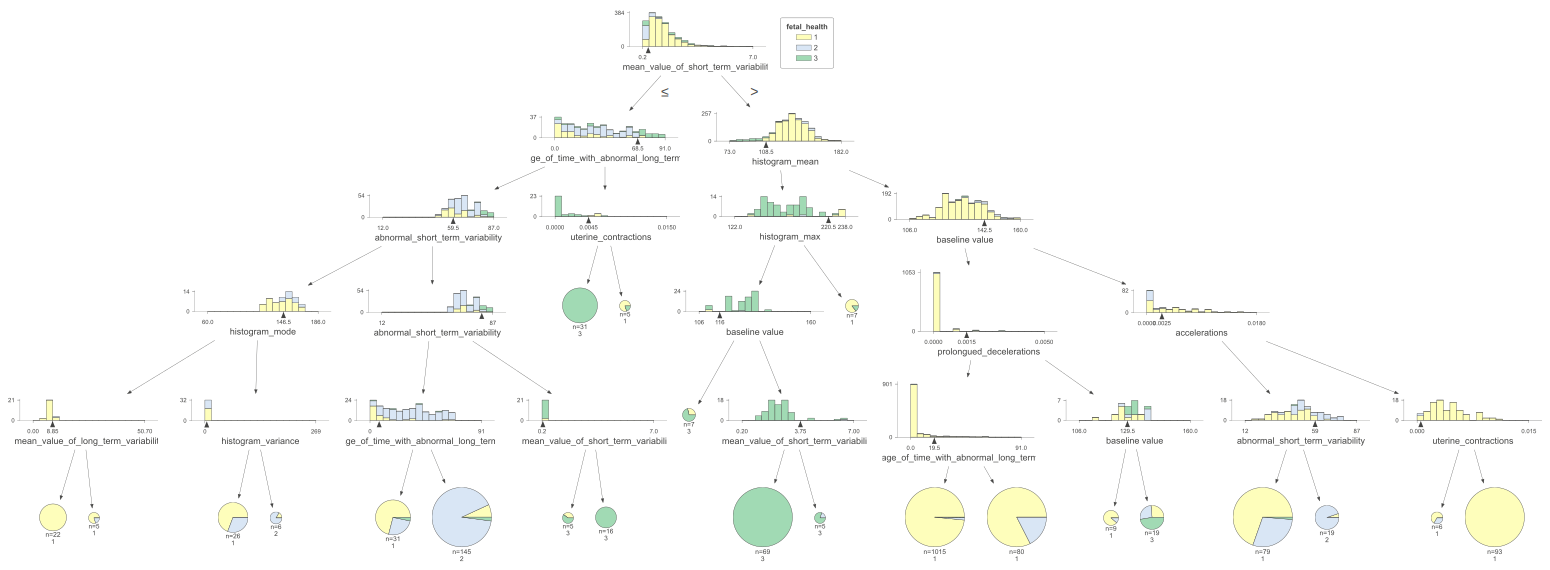

In [43]:
viz = model(
    model= model1,
    X_train=X_train,
    y_train=y_train,
    feature_names=X_train.columns,
    target_name="fetal_health",
    class_names=[1,2,3]
)
viz.view()

In [45]:
# For saving the image
'''

viz.view().save("decisiontree.svg")

'''

'\n\nviz.view().save("decisiontree.svg")\n\n'